# CNN con CIFAR-10

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 5000 images from each class. 

Extraído de https://www.cs.toronto.edu/~kriz/cifar.html

## Carga de datos

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# ToTensor convierte PIL.Image a torch.Tensor
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

print(f'Train: {len(train_dataset)} imagenes')
print(f'Test : {len(test_dataset)} imagenes')
print(f'Shape de una imagen: {train_dataset[0][0].shape}  (C x H x W)')

100%|██████████| 170M/170M [00:05<00:00, 29.2MB/s] 


Train: 50000 imagenes
Test : 10000 imagenes
Shape de una imagen: torch.Size([3, 32, 32])  (C x H x W)


In [2]:
CLASSES = train_dataset.classes
print('Clases:', CLASSES)

Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


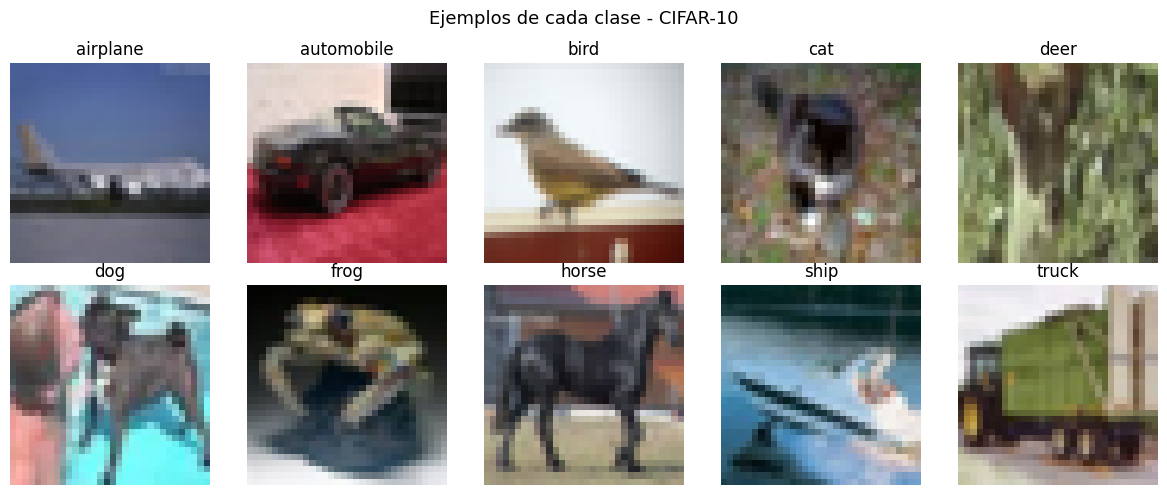

In [4]:
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, cls_idx in zip(axes.flat, range(10)):
    idx = random.choice([i for i, (_, y) in enumerate(train_dataset) if y == cls_idx])
    img, label = train_dataset[idx]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(CLASSES[label])
    ax.axis('off')
plt.suptitle('Ejemplos de cada clase - CIFAR-10', fontsize=13)
plt.tight_layout()
plt.show()

## Modelo

In [7]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# Una clase configurable para la creación de los modelos. 
# Recibe lista de filtros por capa y ek tamaño de la capa oculta y el dropout.
# Para cada capa hacemos Conv2d + ReLU + MaxPool2d(2) y al final aplanamos y pasamos por una capa oculta con dropout antes de la capa de salida.
class CNNModel(nn.Module):
    def __init__(self, filters: list[int], fc_size: int, dropout: float = 0.3):
        super().__init__()

        conv_layers = []
        in_ch = 3  # 3 canales (RGB)
        for out_ch in filters:
            conv_layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2, stride=2),
            ]
            in_ch = out_ch
        self.features = nn.Sequential(*conv_layers)

        # Después de N capas de MaxPool2d(2), el spatial size es 32 / 2^N
        spatial = 32 // (2 ** len(filters))
        flat_size = in_ch * spatial * spatial

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, fc_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_size, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

## Optimizador y función de pérdida

In [ ]:
from torch.optim import Adam

# CrossEntropyLoss porque es un problema de clasificación multiclase.
loss_fn = nn.CrossEntropyLoss()

# Adam como optimizador.
# Como lo único que va a cambiar entre los modelos es la arquitectura, defino los demás hiperparámetros aquí.
LEARNING_RATE = 1e-3
EPOCHS        = 20
BATCH_SIZE    = 64

print(f"Loss    : CrossEntropyLoss")
print(f"Opt     : Adam  (lr={LEARNING_RATE})")
print(f"Épocas  : {EPOCHS}")
print(f"Batch   : {BATCH_SIZE}")

Loss    : CrossEntropyLoss
Opt     : Adam  (lr=0.001)
Épocas  : 20
Batch   : 64
